## NMD Models: Structural Hedge (Caterpillar)

This notebook shows how to develop the structural hedge using the **Caterpillar** approach.

### Input from other components
| Input | From | Use for |
|---|---|---|
| `core_balance`, `wal_years` | Notebook 05 Runoff proflie | Setting target duration |
| `replicating weights` | Notebook 05 Replicating weights | Comparison |

### Core idea
Core deposits have a weighted average life (WAL) of around 3 years, so the Banks should invest the core balance in fixed-rate instruments with a matching duration.


The **Caterpillar** strategy is a rolling hedge approach where the core balance is divided into N tranches. Each tranche is invested at the same target tenor (e.g., 3 years) but at different points in time. As each tranche matures, it is reinvested into a new instrument with the same tenor.


This rolling process ensures that the overall portfolio duration remains stable over time, effectively matching the behavioral duration of core deposits and reducing interest rate risk.

```
Year 1: Tranche 1 → Invest at 5Y
Year 2: Tranche 2 → Invest at 5Y  (Tranche 1 Remaining 4 Year)
Year 3: Tranche 3 → Invest at 5Y  (Tranche 1 Remaining 3 Year, Tranche 2 Remaining 4 Year)
...
Year N: Tranche N → invest at 5Y  (Tranche 1 **Due** Rolling new invest)
```

Result: The average duration = TARGET_TENOR − (N_TRANCHES − 1) / 2

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.caterpillar import optimise_caterpillar
from src.plot_function import plot_caterpillar_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Extract information
market_rate  = df["market_rate"]
deposit_rate = df["deposit_rate"]
balance = df["balance"]

# Show
df[["market_rate", "deposit_rate", "balance"]].describe()

,market_rate,deposit_rate,balance
count,150.000,150.000,150.000
mean,0.049,0.009,5185.951
std,0.007,0.002,335.315
min,0.028,0.004,4523.784
25%,0.044,0.008,4880.310
50%,0.048,0.009,5256.091
75%,0.054,0.010,5414.796
max,0.064,0.012,6083.954


In [4]:
# Import related models
# Import model (HP Model)
with open("../model/hp_model.pkl", "rb") as file:
    hp_result = pickle.load(file)

# Import beta model
with open("../model/beta_model.pkl", "rb") as file:
    beta_result = pickle.load(file)

# Import yield curve
with open("../model/yield_curve.pkl", "rb") as file:
    yield_curve = pickle.load(file)

In [5]:
# Get upstream parameters
WAL_LIABILITY = 2.85  #From runoff proflie
STABLE_PCT = hp_result["stable_pct"]
BETA = beta_result["beta"]

# Core balance = total × stable_pct × (1 - beta)
total_balance_latest = float(balance.iloc[-1])
CORE_BALANCE = total_balance_latest * STABLE_PCT * (1 - BETA)

# Show
print("=" * 60)
print(f"{"Core balance":<{20}}: {CORE_BALANCE:,.2f}")
print(f"{"WAL (liability)":<{20}}: {WAL_LIABILITY:.2f} years")
print("=" * 60)

Core balance        : 3,850.14
WAL (liability)     : 2.85 years


In [6]:
# Maximises portfolio yield with Caterpillar
opt_result = optimise_caterpillar(
    core_balance = CORE_BALANCE,
    wal_liability = WAL_LIABILITY,
    yield_curve = yield_curve,
    tenor_options = [1, 2, 3, 5, 10],
    n_tranche_options = [3, 4, 5, 6, 8, 10],
    max_duration_gap = 0.5
)

# Result
print("=" * 70)
print("Optimised result - Duration gap <= 0.5 year and Duration asset > WAL")
opt_result["feasible"][["tenor", "n_tranches", "avg_duration", "duration_gap", "yield_pct", "nii_annual_mb"]]

Optimised result - Duration gap <= 0.5 year and Duration asset > WAL


,tenor,n_tranches,avg_duration,duration_gap,yield_pct,nii_annual_mb
20,5,5,3.000,0.150,4.850,186.740


In [7]:
# Summary
best = opt_result["best"]

# Result
print("=" * 60)
print(f"{"Target tenor":<{20}}: {best['target_tenor']:.0f} years")
print(f"{"Tranches":<{20}}: {best['n_tranches']:.0f} portions")
print(f"{"Size":<{20}}: {best['tranche_size']:,.2f} MB")
print(f"{"Average duration":<{20}}: {best['avg_duration']:.0f} years")
print(f"{"Liability WAL":<{20}}: {best['wal_liability']:.2f} years")
print(f"{"Duration gap":<{20}}: {best['duration_gap']:+.2f} years")
print(f"{"Portfolio yield":<{20}}: {best['portfolio_yield']:.2%}")
print(f"{"NII Annual":<{20}}: {best['nii_annual']:,.2f} MB")
print("=" * 60)
print("Tranche schedule")
best["schedule"]

Target tenor        : 5 years
Tranches            : 5 portions
Size                : 770.03 MB
Average duration    : 3 years
Liability WAL       : 2.85 years
Duration gap        : +0.15 years
Portfolio yield     : 4.85%
NII Annual          : 186.74 MB
Tranche schedule


,tranche,invest_year,maturity_year,balance_mb,yield_pct,duration_yr
0,T1,1,6.000,770.030,4.850,5.000
1,T2,2,7.000,770.030,4.850,4.000
2,T3,3,8.000,770.030,4.850,3.000
3,T4,4,9.000,770.030,4.850,2.000
4,T5,5,10.000,770.030,4.850,1.000


In [8]:
# NII Sensitivity
print(f"NII Sensitivity | Tranche size = {best['tranche_size']:,.2f} MB | Repricing = 1/{best['n_tranches']} per year")
print()
rows = []
for scenario, vals in best["nii_sensitivity"].items():
    rows.append({
        "scenario": scenario,
        "ΔNII Year 1 (MB)": vals["delta_nii_year1_mb"],
        "ΔNII Fully rolled (MB)": vals["delta_nii_fullroll_mb"],
        "% repricing/year": f"{vals['pct_repricing_year1']:.0%}"
    })
pd.DataFrame(rows).set_index("scenario")

NII Sensitivity | Tranche size = 770.03 MB | Repricing = 1/5 per year



,ΔNII Year 1 (MB),ΔNII Fully rolled (MB),% repricing/year
scenario,,,
+100bps,7.700,38.501,20%
+200bps,15.401,77.003,20%
-100bps,-7.700,-38.501,20%
-200bps,-15.401,-77.003,20%


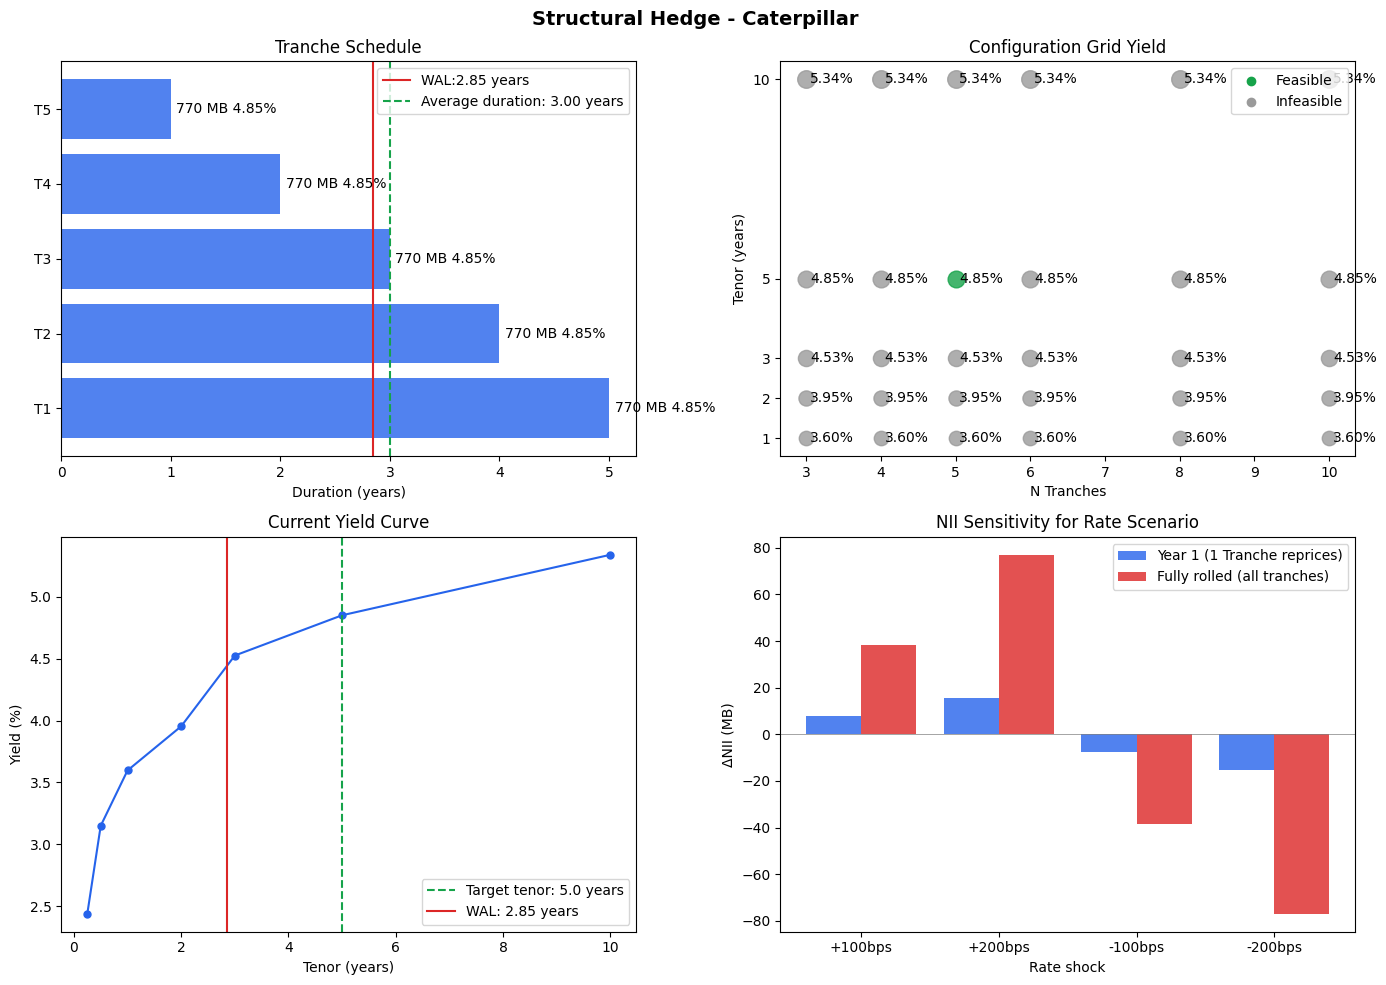

In [9]:
# Plot visualise results
plot_caterpillar_results(
    caterpillar = best,
    opt_result = opt_result,
    yield_curve = yield_curve
)